In [43]:
import scanpy as sc
import anndata
import pandas as pd
import os


In [44]:
base_path = "/mnt/data1/ymy3/IVF-ET/RNA/peripheral_blood/peripheral_total_matrix"

# 假设你想用文件夹名作为样本来源
sample_dirs = ["NP1_matrix", "NP2_matrix", "NP3_matrix", "RP1_matrix", "RP2_matrix", "RP3_matrix"]


In [45]:
adatas = []

for sample in sample_dirs:
    sample_path = os.path.join(base_path, sample)
    
    # 读取 10X 格式数据
    adata = sc.read_10x_mtx(
        sample_path,
        var_names='gene_symbols',  # genes.tsv 的列名作为基因名
        cache=True
    )
    
    # 添加样本来源信息
    adata.obs['sample'] = sample
    
    # 可选：给每个细胞加前缀，避免细胞条码重复
    adata.obs_names = [f"{sample}_{bc}" for bc in adata.obs_names]
    
    adatas.append(adata)


In [46]:
import scanpy as sc
import anndata

# adatas: 已经读取好的单样本列表
adata_all = anndata.concat(
    adatas,
    join='outer',
    label='sample',
    keys=[s for s in sample_dirs],
    fill_value=0  # 缺失基因填 0
)


print("After concat:", adata_all.shape)

# 不计算线粒体 QC
sc.pp.calculate_qc_metrics(adata_all, percent_top=None, inplace=True)

# 过滤细胞
sc.pp.filter_cells(adata_all, min_genes=200)

# 过滤基因
sc.pp.filter_genes(adata_all, min_cells=3)

# 归一化 + log1p
sc.pp.normalize_total(adata_all, target_sum=1e4)


# 保存AnnData对象到.h5ad文件
adata_all.write('./total_counts.h5ad')

sc.pp.log1p(adata_all)

adata_all.X = adata_all.X.astype('float32')

# 保存 raw
adata_all.raw = adata_all


After concat: (85646, 58757)


In [47]:
# 高变基因选择
# ------------------------------
sc.pp.highly_variable_genes(adata_all, flavor='seurat_v3', n_top_genes=2000, batch_key='sample')
adata_all = adata_all[:, adata_all.var.highly_variable]

# 批次校正（可选，使用 BBKNN 或 ComBat）
sc.pp.combat(adata_all, key='sample')

# PCA 降维
# ------------------------------
sc.tl.pca(adata_all, svd_solver='arpack')

# 邻近图和聚类
# ------------------------------
sc.pp.neighbors(adata_all, n_neighbors=10, n_pcs=40)
sc.tl.umap(adata_all)
sc.tl.leiden(adata_all, resolution=0.5)


/home/iluvatar/anaconda3/envs/cell2cell/lib/python3.9/site-packages/scipy/sparse/_index.py:136: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil_matrix is more efficient.
  self._set_arrayXarray_sparse(i, j, x)


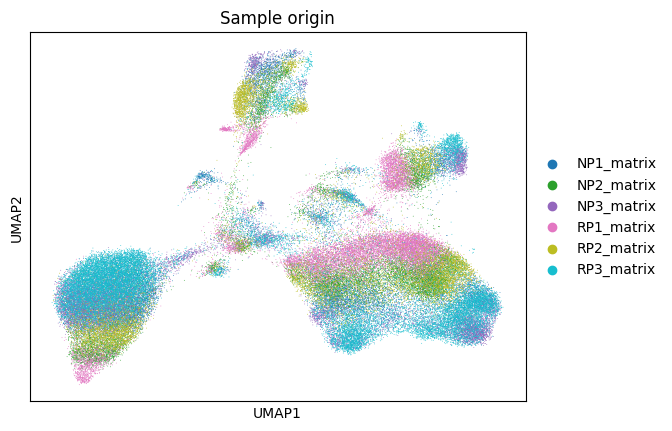

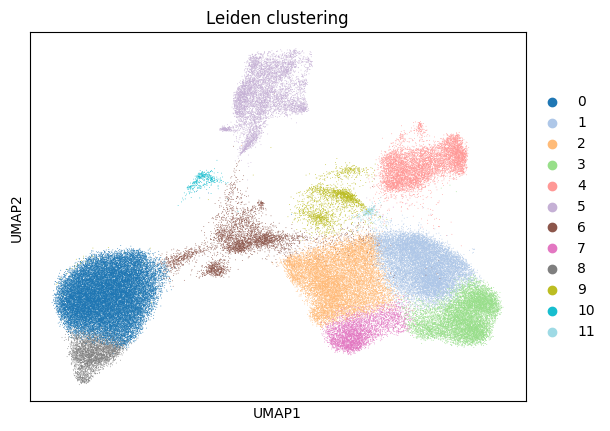

In [48]:
sc.tl.leiden(adata_all, resolution=0.8)

# UMAP 可视化，按 sample 着色
sc.pl.umap(adata_all, color='sample', title='Sample origin', palette='tab10')

# UMAP 按聚类显示
sc.pl.umap(adata_all, color='leiden', title='Leiden clustering', palette='tab20')


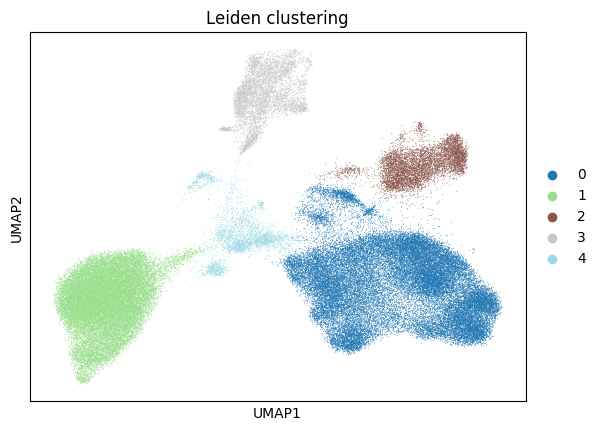

In [49]:
sc.tl.leiden(adata_all, resolution=0.1)

# UMAP 按聚类显示
sc.pl.umap(adata_all, color='leiden', title='Leiden clustering', palette='tab20')


In [ ]:
!pip install celltypist

In [18]:
import celltypist
from celltypist import models

In [51]:
adata_2000 = sc.read('celltypist_demo_folder/demo_2000_cells.h5ad', backup_url = 'https://celltypist.cog.sanger.ac.uk/Notebook_demo_data/demo_2000_cells.h5ad')

In [21]:
# Enabling `force_update = True` will overwrite existing (old) models.
models.download_models(force_update = True)

📜 Retrieving model list from server https://celltypist.cog.sanger.ac.uk/models/models.json
📚 Total models in list: 58
📂 Storing models in /home/iluvatar/.celltypist/data/models
💾 Downloading model [1/58]: Immune_All_Low.pkl
💾 Downloading model [2/58]: Immune_All_High.pkl
💾 Downloading model [3/58]: Adult_COVID19_PBMC.pkl
💾 Downloading model [4/58]: Adult_CynomolgusMacaque_Hippocampus.pkl
💾 Downloading model [5/58]: Adult_Human_MTG.pkl
💾 Downloading model [6/58]: Adult_Human_PancreaticIslet.pkl
💾 Downloading model [7/58]: Adult_Human_PrefrontalCortex.pkl
💾 Downloading model [8/58]: Adult_Human_Skin.pkl
💾 Downloading model [9/58]: Adult_Human_Vascular.pkl
💾 Downloading model [10/58]: Adult_Mouse_Gut.pkl
💾 Downloading model [11/58]: Adult_Mouse_OlfactoryBulb.pkl
💾 Downloading model [12/58]: Adult_Pig_Hippocampus.pkl
💾 Downloading model [13/58]: Adult_RhesusMacaque_Hippocampus.pkl
💾 Downloading model [14/58]: Adult_cHSPCs_Illumina.pkl
💾 Downloading model [15/58]: Adult_cHSPCs_Ultima.pkl
💾 

In [52]:
new_model = celltypist.train(adata_2000, labels = 'cell_type', n_jobs = 10, feature_selection = True)

🍳 Preparing data before training
✂️ 2749 non-expressed genes are filtered out
🔬 Input data has 2000 cells and 16201 genes
⚖️ Scaling input data
🏋️ Training data using SGD logistic regression
🔎 Selecting features
🧬 2628 features are selected
🏋️ Starting the second round of training
🏋️ Training data using logistic regression
✅ Model training done!


In [53]:
# Save the model.
new_model.write('celltypist_demo_folder/model_from_immune2000.pkl')


In [54]:
# Not run; predict the identity of each input cell with the new model.
#predictions = celltypist.annotate(adata_400, model = new_model, majority_voting = True)
# Alternatively, just specify the model path (recommended as this ensures the model is intact every time it is loaded).
predictions = celltypist.annotate(adata_all, model = 'celltypist_demo_folder/model_from_immune2000.pkl', majority_voting = True)

👀 Invalid expression matrix in `.X`, expect log1p normalized expression to 10000 counts per cell; will use `.raw.X` instead
🔬 Input data has 85520 cells and 28782 genes
🔗 Matching reference genes in the model
🧬 2476 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
👀 Detected a neighborhood graph in the input object, will run over-clustering on the basis of it
⛓️ Over-clustering input data with resolution set to 20
🗳️ Majority voting the predictions
✅ Majority voting done!


In [55]:
adata = predictions.to_adata()

In [56]:
adata

AnnData object with n_obs × n_vars = 85520 × 2000
    obs: 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'n_genes', 'leiden', 'predicted_labels', 'over_clustering', 'majority_voting', 'conf_score'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm', 'highly_variable_nbatches'
    uns: 'log1p', 'hvg', 'pca', 'neighbors', 'umap', 'leiden', 'sample_colors', 'leiden_colors'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

In [57]:
adata.obs

,sample,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,n_genes,leiden,predicted_labels,over_clustering,majority_voting,conf_score
NP1_matrix_AAACATCGAAACATCGCCGTGAGA,NP1_matrix,526,6.267201,991.0,6.899723,526,1,Macrophages,524,Macrophages,0.003479
NP1_matrix_AAACATCGAAACATCGCCTCTATC,NP1_matrix,536,6.285998,1200.0,7.090910,536,0,Follicular B cells,174,Follicular B cells,0.112979
NP1_matrix_AAACATCGAAACATCGGAATCTGA,NP1_matrix,662,6.496775,1489.0,7.306531,662,0,gamma-delta T cells,138,Follicular B cells,0.041098
NP1_matrix_AAACATCGAAACATCGGCTCGGTA,NP1_matrix,1876,7.537430,6032.0,8.705000,1876,3,Macrophages,40,Macrophages,0.056064
NP1_matrix_AAACATCGAACAACCAGACTAGTA,NP1_matrix,467,6.148468,832.0,6.725034,467,1,Macrophages,167,Macrophages,0.009359
...,...,...,...,...,...,...,...,...,...,...,...
RP3_matrix_TTCACGCATGGCTTCAAACAACCA,RP3_matrix,405,6.006353,844.0,6.739336,405,0,Follicular B cells,32,gamma-delta T cells,0.120674
RP3_matrix_TTCACGCATGGCTTCAAACGCTTA,RP3_matrix,1006,6.914731,2806.0,7.939872,1006,0,Follicular B cells,0,Follicular B cells,0.054627
RP3_matrix_TTCACGCATTCACGCACCTAATCC,RP3_matrix,540,6.293419,1134.0,7.034388,540,1,Macrophages,397,Macrophages,0.017466
RP3_matrix_TTCACGCATTCACGCAGGTGCGAA,RP3_matrix,493,6.202536,1015.0,6.923629,493,0,Follicular B cells,88,gamma-delta T cells,0.358168


In [58]:
predictions.predicted_labels

,predicted_labels,over_clustering,majority_voting
NP1_matrix_AAACATCGAAACATCGCCGTGAGA,Macrophages,524,Macrophages
NP1_matrix_AAACATCGAAACATCGCCTCTATC,Follicular B cells,174,Follicular B cells
NP1_matrix_AAACATCGAAACATCGGAATCTGA,gamma-delta T cells,138,Follicular B cells
NP1_matrix_AAACATCGAAACATCGGCTCGGTA,Macrophages,40,Macrophages
NP1_matrix_AAACATCGAACAACCAGACTAGTA,Macrophages,167,Macrophages
...,...,...,...
RP3_matrix_TTCACGCATGGCTTCAAACAACCA,Follicular B cells,32,gamma-delta T cells
RP3_matrix_TTCACGCATGGCTTCAAACGCTTA,Follicular B cells,0,Follicular B cells
RP3_matrix_TTCACGCATTCACGCACCTAATCC,Macrophages,397,Macrophages
RP3_matrix_TTCACGCATTCACGCAGGTGCGAA,Follicular B cells,88,gamma-delta T cells


In [59]:
adata_all.obs['celltypist_labels'] = predictions.predicted_labels['majority_voting']

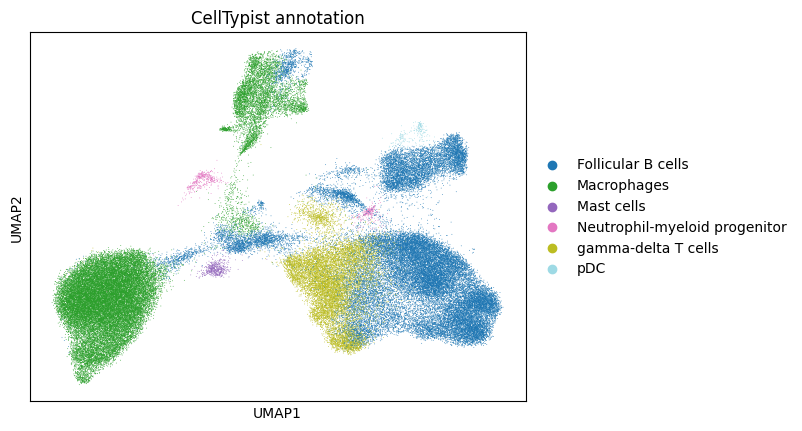

In [60]:
import scanpy as sc

# 重新计算邻近图和 UMAP
#sc.pp.neighbors(adata_all, n_neighbors=10, n_pcs=40)
#sc.tl.umap(adata_all)

# 可视化
sc.pl.umap(
    adata_all, 
    color='celltypist_labels', 
    palette='tab20', 
    title='CellTypist annotation'
)


In [61]:
adata_all.obs

,sample,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,n_genes,leiden,predicted_labels,over_clustering,majority_voting,conf_score,celltypist_labels
NP1_matrix_AAACATCGAAACATCGCCGTGAGA,NP1_matrix,526,6.267201,991.0,6.899723,526,1,Macrophages,524,Macrophages,0.003479,Macrophages
NP1_matrix_AAACATCGAAACATCGCCTCTATC,NP1_matrix,536,6.285998,1200.0,7.090910,536,0,Follicular B cells,174,Follicular B cells,0.112979,Follicular B cells
NP1_matrix_AAACATCGAAACATCGGAATCTGA,NP1_matrix,662,6.496775,1489.0,7.306531,662,0,gamma-delta T cells,138,Follicular B cells,0.041098,Follicular B cells
NP1_matrix_AAACATCGAAACATCGGCTCGGTA,NP1_matrix,1876,7.537430,6032.0,8.705000,1876,3,Macrophages,40,Macrophages,0.056064,Macrophages
NP1_matrix_AAACATCGAACAACCAGACTAGTA,NP1_matrix,467,6.148468,832.0,6.725034,467,1,Macrophages,167,Macrophages,0.009359,Macrophages
...,...,...,...,...,...,...,...,...,...,...,...,...
RP3_matrix_TTCACGCATGGCTTCAAACAACCA,RP3_matrix,405,6.006353,844.0,6.739336,405,0,Follicular B cells,32,gamma-delta T cells,0.120674,gamma-delta T cells
RP3_matrix_TTCACGCATGGCTTCAAACGCTTA,RP3_matrix,1006,6.914731,2806.0,7.939872,1006,0,Follicular B cells,0,Follicular B cells,0.054627,Follicular B cells
RP3_matrix_TTCACGCATTCACGCACCTAATCC,RP3_matrix,540,6.293419,1134.0,7.034388,540,1,Macrophages,397,Macrophages,0.017466,Macrophages
RP3_matrix_TTCACGCATTCACGCAGGTGCGAA,RP3_matrix,493,6.202536,1015.0,6.923629,493,0,Follicular B cells,88,gamma-delta T cells,0.358168,gamma-delta T cells


In [62]:
import pandas as pd

# 统计每个 sample 中每个细胞类型的数量
cell_counts = adata_all.obs.groupby(['sample', 'celltypist_labels']).size().reset_index(name='count')

# 查看前几行
print(cell_counts.head())


       sample              celltypist_labels  count
0  NP1_matrix             Follicular B cells   5094
1  NP1_matrix                    Macrophages   7264
2  NP1_matrix                     Mast cells     52
3  NP1_matrix  Neutrophil-myeloid progenitor    255
4  NP1_matrix            gamma-delta T cells   1905


In [63]:
cell_counts

,sample,celltypist_labels,count
0,NP1_matrix,Follicular B cells,5094
1,NP1_matrix,Macrophages,7264
2,NP1_matrix,Mast cells,52
3,NP1_matrix,Neutrophil-myeloid progenitor,255
4,NP1_matrix,gamma-delta T cells,1905
5,NP1_matrix,pDC,67
6,NP2_matrix,Follicular B cells,7049
7,NP2_matrix,Macrophages,3962
8,NP2_matrix,Mast cells,168
9,NP2_matrix,Neutrophil-myeloid progenitor,35


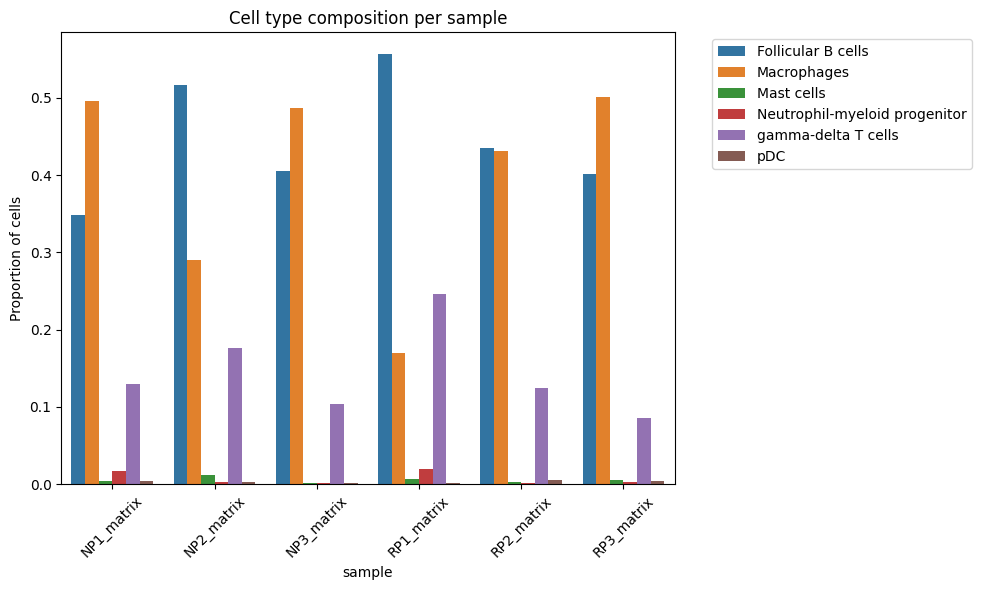

In [64]:
import matplotlib.pyplot as plt
import seaborn as sns

# 计算比例
cell_counts['proportion'] = cell_counts.groupby('sample')['count'].transform(lambda x: x / x.sum())

# 绘制堆积柱状图
plt.figure(figsize=(10,6))
sns.barplot(
    data=cell_counts,
    x='sample',
    y='proportion',
    hue='celltypist_labels'
)
plt.ylabel('Proportion of cells')
plt.title('Cell type composition per sample')
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')  # 图例放右边
plt.tight_layout()
plt.show()


In [65]:
import pandas as pd

# 只保留 sample 名称包含 'NP' 或 'RP' 的行
obs_filtered = adata_all.obs[adata_all.obs['sample'].str.contains('NP|RP')]

# 检查一下结果
print(obs_filtered['sample'].unique())


['NP1_matrix', 'NP2_matrix', 'NP3_matrix', 'RP1_matrix', 'RP2_matrix', 'RP3_matrix']
Categories (6, object): ['NP1_matrix', 'NP2_matrix', 'NP3_matrix', 'RP1_matrix', 'RP2_matrix', 'RP3_matrix']


In [66]:
cell_counts = obs_filtered.groupby(['sample', 'celltypist_labels']).size().reset_index(name='count')
cell_counts['proportion'] = cell_counts.groupby('sample')['count'].transform(lambda x: x / x.sum())

print(cell_counts.head())


       sample              celltypist_labels  count  proportion
0  NP1_matrix             Follicular B cells   5094    0.348022
1  NP1_matrix                    Macrophages   7264    0.496277
2  NP1_matrix                     Mast cells     52    0.003553
3  NP1_matrix  Neutrophil-myeloid progenitor    255    0.017422
4  NP1_matrix            gamma-delta T cells   1905    0.130150


In [67]:
cell_counts

,sample,celltypist_labels,count,proportion
0,NP1_matrix,Follicular B cells,5094,0.348022
1,NP1_matrix,Macrophages,7264,0.496277
2,NP1_matrix,Mast cells,52,0.003553
3,NP1_matrix,Neutrophil-myeloid progenitor,255,0.017422
4,NP1_matrix,gamma-delta T cells,1905,0.130150
5,NP1_matrix,pDC,67,0.004577
6,NP2_matrix,Follicular B cells,7049,0.516372
7,NP2_matrix,Macrophages,3962,0.290235
8,NP2_matrix,Mast cells,168,0.012307
9,NP2_matrix,Neutrophil-myeloid progenitor,35,0.002564


In [68]:
import pandas as pd

# 复制 obs 防止修改原数据
obs_filtered = adata_all.obs.copy()

# 简化 sample 名称，只保留 NP 或 RP
obs_filtered['sample_simple'] = obs_filtered['sample'].str.extract(r'(NP|RP)')

# 检查结果
print(obs_filtered['sample_simple'].unique())


['NP' 'RP']


In [69]:
# 统计每类样本的细胞数量
sample_counts = obs_filtered['sample_simple'].value_counts().reset_index()
sample_counts.columns = ['sample_simple', 'count']

# 计算比例
sample_counts['proportion'] = sample_counts['count'] / sample_counts['count'].sum()

print(sample_counts)


  sample_simple  count  proportion
0            RP  46135    0.539464
1            NP  39385    0.460536


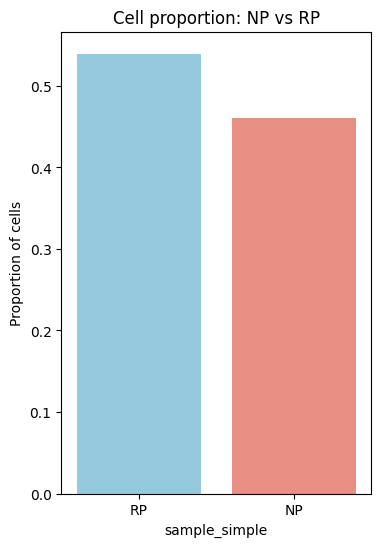

In [70]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(4,6))
sns.barplot(
    data=sample_counts,
    x='sample_simple',
    y='proportion',
    palette=['skyblue','salmon']
)
plt.ylabel('Proportion of cells')
plt.title('Cell proportion: NP vs RP')
plt.show()


... storing 'sample_simple' as categorical


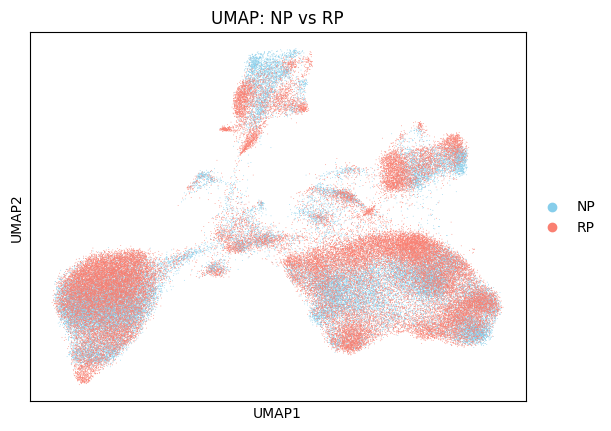

In [71]:
adata_all.obs['sample_simple'] = adata_all.obs['sample'].str.extract(r'(NP|RP)')

sc.pl.umap(
    adata_all,
    color='sample_simple',
    palette=['skyblue','salmon'],
    title='UMAP: NP vs RP'
)


In [72]:
sample_counts = adata_all.obs['sample_simple'].value_counts().reset_index()
sample_counts.columns = ['sample_simple', 'count']
sample_counts['proportion'] = sample_counts['count'] / sample_counts['count'].sum()


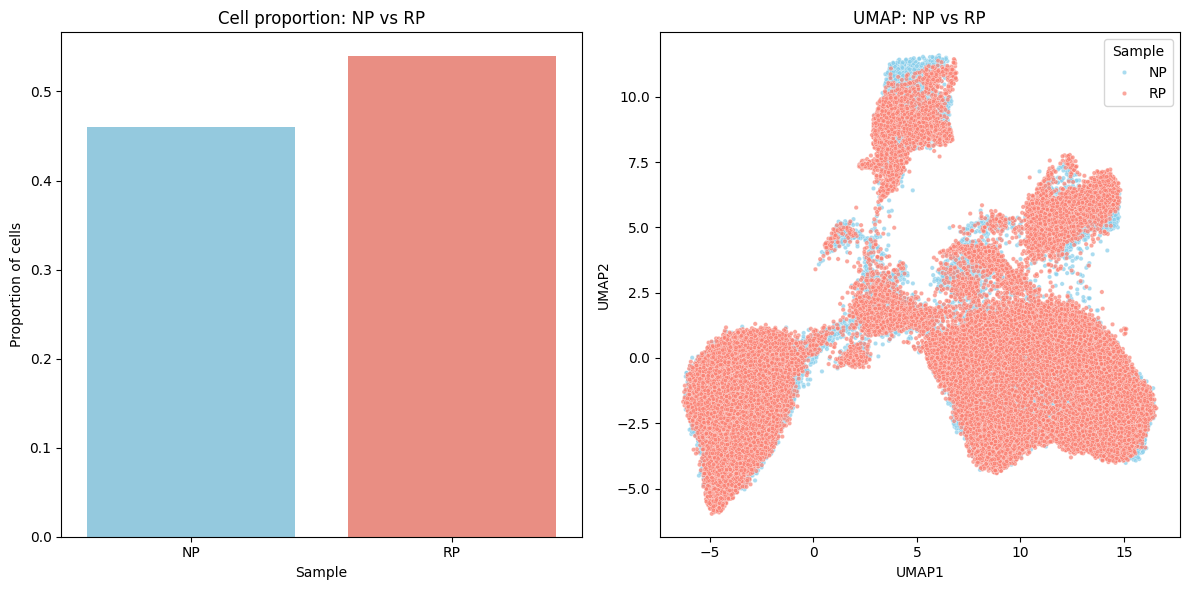

In [73]:
fig, axes = plt.subplots(1, 2, figsize=(12,6))

# 左边：柱状图
sns.barplot(
    data=sample_counts,
    x='sample_simple',
    y='proportion',
    palette=['skyblue','salmon'],
    ax=axes[0]
)
axes[0].set_ylabel('Proportion of cells')
axes[0].set_xlabel('Sample')
axes[0].set_title('Cell proportion: NP vs RP')

# 右边：UMAP
# 先提取 UMAP 坐标
umap_df = pd.DataFrame(adata_all.obsm['X_umap'], index=adata_all.obs_names, columns=['UMAP1','UMAP2'])
umap_df = umap_df.join(adata_all.obs['sample_simple'])

sns.scatterplot(
    data=umap_df,
    x='UMAP1',
    y='UMAP2',
    hue='sample_simple',
    palette=['skyblue','salmon'],
    s=10,
    alpha=0.7,
    ax=axes[1]
)
axes[1].set_title('UMAP: NP vs RP')
axes[1].legend(title='Sample', loc='upper right')

plt.tight_layout()
plt.show()

In [74]:
import os

# 创建文件夹
os.makedirs('/mnt/data1/ymy3/IVF-ET/RNA/peripheral_blood/peripheral_total_matrix/', exist_ok=True)

# 保存文件
adata_all.write('./adata_all_processed.h5ad')


In [ ]:
adata_all.obs

In [ ]:
import scanpy as sc

# 加载处理好的文件
adata_all = sc.read_h5ad('./adata_all_processed.h5ad')


In [75]:

# 如果不存在，先创建
adata_all.obs['sample_simple'] = adata_all.obs['sample'].str.extract(r'(NP|RP)')

# 只保留 NP 样本
adata_NP = adata_all[adata_all.obs['sample_simple'] == 'NP'].copy()


# 运行cellphone

In [ ]:
import anndata
import pandas as pd
import anndata
import scanpy as sc
import pandas as pd
import numpy as np
import h5py

adata=anndata.read("/mnt/data_8t/hit-dachuang/adata_all_processed.h5ad")
adata.obs

In [ ]:
adata

In [ ]:

# 如果不存在，先创建
adata.obs['sample_simple'] = adata.obs['sample'].str.extract(r'(NP|RP)')

# 只保留 NP 样本
adata_NP = adata[adata.obs['sample_simple'] == 'NP'].copy()


In [ ]:
adata_NP

In [ ]:
#提取counts数据

In [76]:
import anndata
import pandas as pd
adata=anndata.read("/mnt/data_8t/hit-dachuang/total_counts.h5ad")

In [77]:
adata

AnnData object with n_obs × n_vars = 85520 × 28782
    obs: 'sample', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'n_genes'
    var: 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'

In [78]:
adata.obs

,sample,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,n_genes
NP1_matrix_AAACATCGAAACATCGCCGTGAGA,NP1_matrix,526,6.267201,991.0,6.899723,526
NP1_matrix_AAACATCGAAACATCGCCTCTATC,NP1_matrix,536,6.285998,1200.0,7.090910,536
NP1_matrix_AAACATCGAAACATCGGAATCTGA,NP1_matrix,662,6.496775,1489.0,7.306531,662
NP1_matrix_AAACATCGAAACATCGGCTCGGTA,NP1_matrix,1876,7.537430,6032.0,8.705000,1876
NP1_matrix_AAACATCGAACAACCAGACTAGTA,NP1_matrix,467,6.148468,832.0,6.725034,467
...,...,...,...,...,...,...
RP3_matrix_TTCACGCATGGCTTCAAACAACCA,RP3_matrix,405,6.006353,844.0,6.739336,405
RP3_matrix_TTCACGCATGGCTTCAAACGCTTA,RP3_matrix,1006,6.914731,2806.0,7.939872,1006
RP3_matrix_TTCACGCATTCACGCACCTAATCC,RP3_matrix,540,6.293419,1134.0,7.034388,540
RP3_matrix_TTCACGCATTCACGCAGGTGCGAA,RP3_matrix,493,6.202536,1015.0,6.923629,493


In [79]:
import pandas as pd

# 复制 obs 防止修改原数据
obs_filtered = adata.obs.copy()

# 简化 sample 名称，只保留 NP 或 RP
obs_filtered['sample_simple'] = obs_filtered['sample'].str.extract(r'(NP|RP)')

# 检查结果
print(obs_filtered['sample_simple'].unique())


['NP' 'RP']


In [80]:
# 统计每类样本的细胞数量
sample_counts = obs_filtered['sample_simple'].value_counts().reset_index()
sample_counts.columns = ['sample_simple', 'count']

# 计算比例
sample_counts['proportion'] = sample_counts['count'] / sample_counts['count'].sum()

print(sample_counts)


  sample_simple  count  proportion
0            RP  46135    0.539464
1            NP  39385    0.460536


In [81]:
# 如果不存在，先创建
adata.obs['sample_simple'] = adata.obs['sample'].str.extract(r'(NP|RP)')

# 只保留 NP 样本
adata_NP1 = adata[adata.obs['sample_simple'] == 'NP'].copy()


In [82]:
adata_NP1.obs

,sample,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,n_genes,sample_simple
NP1_matrix_AAACATCGAAACATCGCCGTGAGA,NP1_matrix,526,6.267201,991.0,6.899723,526,NP
NP1_matrix_AAACATCGAAACATCGCCTCTATC,NP1_matrix,536,6.285998,1200.0,7.090910,536,NP
NP1_matrix_AAACATCGAAACATCGGAATCTGA,NP1_matrix,662,6.496775,1489.0,7.306531,662,NP
NP1_matrix_AAACATCGAAACATCGGCTCGGTA,NP1_matrix,1876,7.537430,6032.0,8.705000,1876,NP
NP1_matrix_AAACATCGAACAACCAGACTAGTA,NP1_matrix,467,6.148468,832.0,6.725034,467,NP
...,...,...,...,...,...,...,...
NP3_matrix_TTCACGCATGAAGAGACACCTTAC,NP3_matrix,799,6.684612,2445.0,7.802209,799,NP
NP3_matrix_TTCACGCATGGAACAAACACAGAA,NP3_matrix,713,6.570883,1779.0,7.484369,713,NP
NP3_matrix_TTCACGCATGGAACAACCTCCTGA,NP3_matrix,777,6.656727,2263.0,7.724888,777,NP
NP3_matrix_TTCACGCATGGAACAACGCATACA,NP3_matrix,388,5.963579,693.0,6.542472,388,NP


In [83]:
adata_NP1.X

<39385x28782 sparse matrix of type '<class 'numpy.float32'>'
	with 28863393 stored elements in Compressed Sparse Row format>

In [ ]:
#提取meta数据

In [84]:
import scanpy as sc

aData = sc.read_h5ad("/mnt/data_8t/hit-dachuang/adata_all_processed.h5ad")

In [85]:
aData.obs

,sample,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,n_genes,leiden,predicted_labels,over_clustering,majority_voting,conf_score,celltypist_labels,sample_simple
NP1_matrix_AAACATCGAAACATCGCCGTGAGA,NP1_matrix,526,6.267201,991.0,6.899723,526,1,Macrophages,524,Macrophages,0.003479,Macrophages,NP
NP1_matrix_AAACATCGAAACATCGCCTCTATC,NP1_matrix,536,6.285998,1200.0,7.090910,536,0,Follicular B cells,174,Follicular B cells,0.112979,Follicular B cells,NP
NP1_matrix_AAACATCGAAACATCGGAATCTGA,NP1_matrix,662,6.496775,1489.0,7.306531,662,0,gamma-delta T cells,138,Follicular B cells,0.041098,Follicular B cells,NP
NP1_matrix_AAACATCGAAACATCGGCTCGGTA,NP1_matrix,1876,7.537430,6032.0,8.705000,1876,3,Macrophages,40,Macrophages,0.056064,Macrophages,NP
NP1_matrix_AAACATCGAACAACCAGACTAGTA,NP1_matrix,467,6.148468,832.0,6.725034,467,1,Macrophages,167,Macrophages,0.009359,Macrophages,NP
...,...,...,...,...,...,...,...,...,...,...,...,...,...
RP3_matrix_TTCACGCATGGCTTCAAACAACCA,RP3_matrix,405,6.006353,844.0,6.739336,405,0,Follicular B cells,32,gamma-delta T cells,0.120674,gamma-delta T cells,RP
RP3_matrix_TTCACGCATGGCTTCAAACGCTTA,RP3_matrix,1006,6.914731,2806.0,7.939872,1006,0,Follicular B cells,0,Follicular B cells,0.054627,Follicular B cells,RP
RP3_matrix_TTCACGCATTCACGCACCTAATCC,RP3_matrix,540,6.293419,1134.0,7.034388,540,1,Macrophages,397,Macrophages,0.017466,Macrophages,RP
RP3_matrix_TTCACGCATTCACGCAGGTGCGAA,RP3_matrix,493,6.202536,1015.0,6.923629,493,0,Follicular B cells,88,gamma-delta T cells,0.358168,gamma-delta T cells,RP


In [86]:
# 只保留 NP 样本
adata_NP2 = aData[aData.obs['sample_simple'] == 'NP'].copy()


In [87]:
adata_NP2.obs

,sample,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,n_genes,leiden,predicted_labels,over_clustering,majority_voting,conf_score,celltypist_labels,sample_simple
NP1_matrix_AAACATCGAAACATCGCCGTGAGA,NP1_matrix,526,6.267201,991.0,6.899723,526,1,Macrophages,524,Macrophages,0.003479,Macrophages,NP
NP1_matrix_AAACATCGAAACATCGCCTCTATC,NP1_matrix,536,6.285998,1200.0,7.090910,536,0,Follicular B cells,174,Follicular B cells,0.112979,Follicular B cells,NP
NP1_matrix_AAACATCGAAACATCGGAATCTGA,NP1_matrix,662,6.496775,1489.0,7.306531,662,0,gamma-delta T cells,138,Follicular B cells,0.041098,Follicular B cells,NP
NP1_matrix_AAACATCGAAACATCGGCTCGGTA,NP1_matrix,1876,7.537430,6032.0,8.705000,1876,3,Macrophages,40,Macrophages,0.056064,Macrophages,NP
NP1_matrix_AAACATCGAACAACCAGACTAGTA,NP1_matrix,467,6.148468,832.0,6.725034,467,1,Macrophages,167,Macrophages,0.009359,Macrophages,NP
...,...,...,...,...,...,...,...,...,...,...,...,...,...
NP3_matrix_TTCACGCATGAAGAGACACCTTAC,NP3_matrix,799,6.684612,2445.0,7.802209,799,1,Macrophages,277,Macrophages,0.027519,Macrophages,NP
NP3_matrix_TTCACGCATGGAACAAACACAGAA,NP3_matrix,713,6.570883,1779.0,7.484369,713,1,Macrophages,516,Macrophages,0.024973,Macrophages,NP
NP3_matrix_TTCACGCATGGAACAACCTCCTGA,NP3_matrix,777,6.656727,2263.0,7.724888,777,1,Macrophages,292,Macrophages,0.241381,Macrophages,NP
NP3_matrix_TTCACGCATGGAACAACGCATACA,NP3_matrix,388,5.963579,693.0,6.542472,388,4,Follicular B cells,2,Follicular B cells,0.354926,Follicular B cells,NP


In [91]:
meta_data = adata_NP2.obs.copy()
meta_data.reset_index(inplace=True)  # 将索引转为列
meta_data.rename(columns={'index': 'Cell', 'majority_voting': 'cell_type'}, inplace=True)  # 重命名列

# 选择需要的列，并调整列顺序以符合cellphoneDB格式
meta_data = meta_data[['Cell', 'cell_type']]

# 输出头几行以检查
print(meta_data.head())


                                  Cell           cell_type
0  NP1_matrix_AAACATCGAAACATCGCCGTGAGA         Macrophages
1  NP1_matrix_AAACATCGAAACATCGCCTCTATC  Follicular B cells
2  NP1_matrix_AAACATCGAAACATCGGAATCTGA  Follicular B cells
3  NP1_matrix_AAACATCGAAACATCGGCTCGGTA         Macrophages
4  NP1_matrix_AAACATCGAACAACCAGACTAGTA         Macrophages


In [92]:
# 保存为 TXT 文件，确保不包括索引
meta_data.to_csv('/mnt/data_8t/hit-dachuang/total_meta.txt', sep='\t', index=False)

In [94]:
import pandas as pd

# 设置 pandas 显示最大类别数量为 1000，确保所有细胞类型都能显示
pd.set_option('display.max_categories', 1000)

# 获取不重复的细胞类型并打印
unique_cell_types = adata_NP2.obs['majority_voting'].unique()
print(unique_cell_types)


['Macrophages', 'Follicular B cells', 'Mast cells', 'Neutrophil-myeloid progenitor', 'gamma-delta T cells', 'pDC']
Categories (6, object): ['Follicular B cells', 'Macrophages', 'Mast cells', 'Neutrophil-myeloid progenitor', 'gamma-delta T cells', 'pDC']


In [1]:
import pandas as pd
import sys
import os

cpdb_file_path = '/home/iluvatar/Desktop/ymy/HIT/cell2cell/cpdb/v5.0.0/cellphonedb.zip'
meta_file_path = '/mnt/data_8t/hit-dachuang/total_meta.txt'
counts_file_path = '/mnt/data_8t/hit-dachuang/total_counts.h5ad'
out_path = '/mnt/data_8t/hit-dachuang'


In [2]:
metadata = pd.read_csv(meta_file_path, sep = '\t')
metadata.head(3)

,Cell,cell_type
0,NP1_matrix_AAACATCGAAACATCGCCGTGAGA,Macrophages
1,NP1_matrix_AAACATCGAAACATCGCCTCTATC,Follicular B cells
2,NP1_matrix_AAACATCGAAACATCGGAATCTGA,Follicular B cells


In [3]:
import anndata

adata = anndata.read_h5ad(counts_file_path)
adata.shape

(85520, 28782)

In [4]:
list(adata.obs.index).sort() == list(metadata['Cell']).sort()

True

In [5]:
from cellphonedb.src.core.methods import cpdb_statistical_analysis_method

cpdb_results = cpdb_statistical_analysis_method.call(
    cpdb_file_path = cpdb_file_path,                 # mandatory: CellphoneDB database zip file.
    meta_file_path = meta_file_path,                 # mandatory: tsv file defining barcodes to cell label.
    counts_file_path = counts_file_path,             # mandatory: normalized count matrix - a path to the counts file, or an in-memory AnnData object
    counts_data = 'hgnc_symbol',                     # defines the gene annotation in counts matrix.
    #active_tfs_file_path = active_tf_path,           # optional: defines cell types and their active TFs.
    #microenvs_file_path = microenvs_file_path,       # optional (default: None): defines cells per microenvironment.
    score_interactions = True,                       # optional: whether to score interactions or not. 
    iterations = 1000,                               # denotes the number of shufflings performed in the analysis.
    threshold = 0.1,                                 # defines the min % of cells expressing a gene for this to be employed in the analysis.
    threads = 5,                                     # number of threads to use in the analysis.
    debug_seed = 42,                                 # debug randome seed. To disable >=0.
    result_precision = 3,                            # Sets the rounding for the mean values in significan_means.
    pvalue = 0.05,                                   # P-value threshold to employ for significance.
    subsampling = False,                             # To enable subsampling the data (geometri sketching).
    subsampling_log = False,                         # (mandatory) enable subsampling log1p for non log-transformed data inputs.
    subsampling_num_pc = 100,                        # Number of componets to subsample via geometric skectching (dafault: 100).
    subsampling_num_cells = 1000,                    # Number of cells to subsample (integer) (default: 1/3 of the dataset).
    separator = '|',                                 # Sets the string to employ to separate cells in the results dataframes "cellA|CellB".
    debug = False,                                   # Saves all intermediate tables employed during the analysis in pkl format.
    output_path = out_path,                          # Path to save results.
    output_suffix = None                             # Replaces the timestamp in the output files by a user defined string in the  (default: None).
    )

Reading user files...
The following user files were loaded successfully:
/mnt/data_8t/hit-dachuang/total_counts.h5ad
/mnt/data_8t/hit-dachuang/total_meta.txt
[ ][CORE][20/10/25-22:17:35][INFO] [Cluster Statistical Analysis] Threshold:0.1 Iterations:1000 Debug-seed:42 Threads:5 Precision:3
[ ][CORE][20/10/25-22:17:35][WARNING] Debug random seed enabled. Set to 42
[ ][CORE][20/10/25-22:17:37][INFO] Running Real Analysis
[ ][CORE][20/10/25-22:17:37][INFO] Running Statistical Analysis


100%|███████████████████████████████████████| 1000/1000 [04:17<00:00,  3.88it/s]

[ ][CORE][20/10/25-22:21:55][INFO] Building Pvalues result
[ ][CORE][20/10/25-22:21:55][INFO] Building results


[ ][CORE][20/10/25-22:21:55][INFO] Scoring interactions: Filtering genes per cell type..


100%|█████████████████████████████████████████████| 6/6 [00:00<00:00, 16.23it/s]

[ ][CORE][20/10/25-22:21:56][INFO] Scoring interactions: Calculating mean expression of each gene per group/cell type..



100%|█████████████████████████████████████████████| 6/6 [00:00<00:00, 38.63it/s]


[ ][CORE][20/10/25-22:21:56][INFO] Scoring interactions: Calculating scores for all interactions and cell types..


100%|███████████████████████████████████████████| 36/36 [00:03<00:00,  9.04it/s]


Saved deconvoluted to /mnt/data_8t/hit-dachuang/statistical_analysis_deconvoluted_10_20_2025_222201.txt
Saved deconvoluted_percents to /mnt/data_8t/hit-dachuang/statistical_analysis_deconvoluted_percents_10_20_2025_222201.txt
Saved means to /mnt/data_8t/hit-dachuang/statistical_analysis_means_10_20_2025_222201.txt
Saved pvalues to /mnt/data_8t/hit-dachuang/statistical_analysis_pvalues_10_20_2025_222201.txt
Saved significant_means to /mnt/data_8t/hit-dachuang/statistical_analysis_significant_means_10_20_2025_222201.txt
Saved interaction_scores to /mnt/data_8t/hit-dachuang/statistical_analysis_interaction_scores_10_20_2025_222201.txt


In [7]:
from cellphonedb.utils import search_utils

search_results = search_utils.search_analysis_results(
    query_cell_types_1 = ['Follicular B cells', 'Macrophages', 'Mast cells', 'Neutrophil-myeloid progenitor', 'gamma-delta T cells', 'pDC'],
    query_cell_types_2 = ['Follicular B cells', 'Macrophages', 'Mast cells', 'Neutrophil-myeloid progenitor', 'gamma-delta T cells', 'pDC'],
    #query_genes = ['TGFBR1'],                                       # filter interactions based on the genes participating (list).
    #query_interactions = ['CSF1_CSF1R'],                            # filter intereactions based on their name (list).
    significant_means = cpdb_results['significant_means'],          # significant_means file generated by CellphoneDB.
    deconvoluted = cpdb_results['deconvoluted'],                    # devonvoluted file generated by CellphoneDB.
    interaction_scores = cpdb_results['interaction_scores'],        # interaction score generated by CellphoneDB.
    query_minimum_score = 50,                                       # minimum score that an interaction must have to be filtered.
    separator = '|',                                                # separator (default: |) employed to split cells (cellA|cellB).
    long_format = True                                             # converts the output into a wide table, removing non-significant interactions
    #query_classifications = ['Signaling by Transforming growth factor']
)

search_results

,interacting_pair,partner_a,partner_b,gene_a,gene_b,directionality,classification,interacting_cells,significant_mean
35,KLRB1_CLEC2D,simple:Q12918,simple:Q9UHP7,KLRB1,CLEC2D,Ligand-Receptor,NaN,Follicular B cells|Follicular B cells,1.194000
98,SEMA4D_PTPRC,simple:Q92854,simple:P08575,SEMA4D,PTPRC,Ligand-Receptor,Signaling by Semaphorin,Follicular B cells|Macrophages,10.065000
100,CD44_TYROBP,simple:P16070,simple:O43914,CD44,TYROBP,Ligand-Receptor,NaN,Follicular B cells|Macrophages,17.145000
101,HLA-F_LILRB2,simple:P30511,simple:Q8N423,HLA-F,LILRB2,Ligand-Receptor,Signaling by HLA,Follicular B cells|Macrophages,1.829000
102,CD99_PILRA,simple:P14209,simple:Q9UKJ1,CD99,PILRA,Ligand-Receptor,NaN,Follicular B cells|Macrophages,3.122000
...,...,...,...,...,...,...,...,...,...
1946,MPZL1_MPZL1,simple:O95297,simple:O95297,MPZL1,MPZL1,Adhesion-Adhesion,NaN,pDC|pDC,0.745000
1958,APP_TNFRSF21,simple:P05067,simple:O75509,APP,TNFRSF21,Ligand-Receptor,Signaling by Amyloid-beta precursor protein,pDC|pDC,3.436000
1969,LAIR1_LILRB4,simple:Q6GTX8,simple:Q8NHJ6,LAIR1,LILRB4,Receptor-Receptor,NaN,pDC|pDC,0.570000
1971,APP_CD74,simple:P05067,simple:P04233,APP,CD74,Ligand-Receptor,Signaling by Amyloid-beta precursor protein,pDC|pDC,155.285995


In [8]:
search_results.shape

(210, 9)

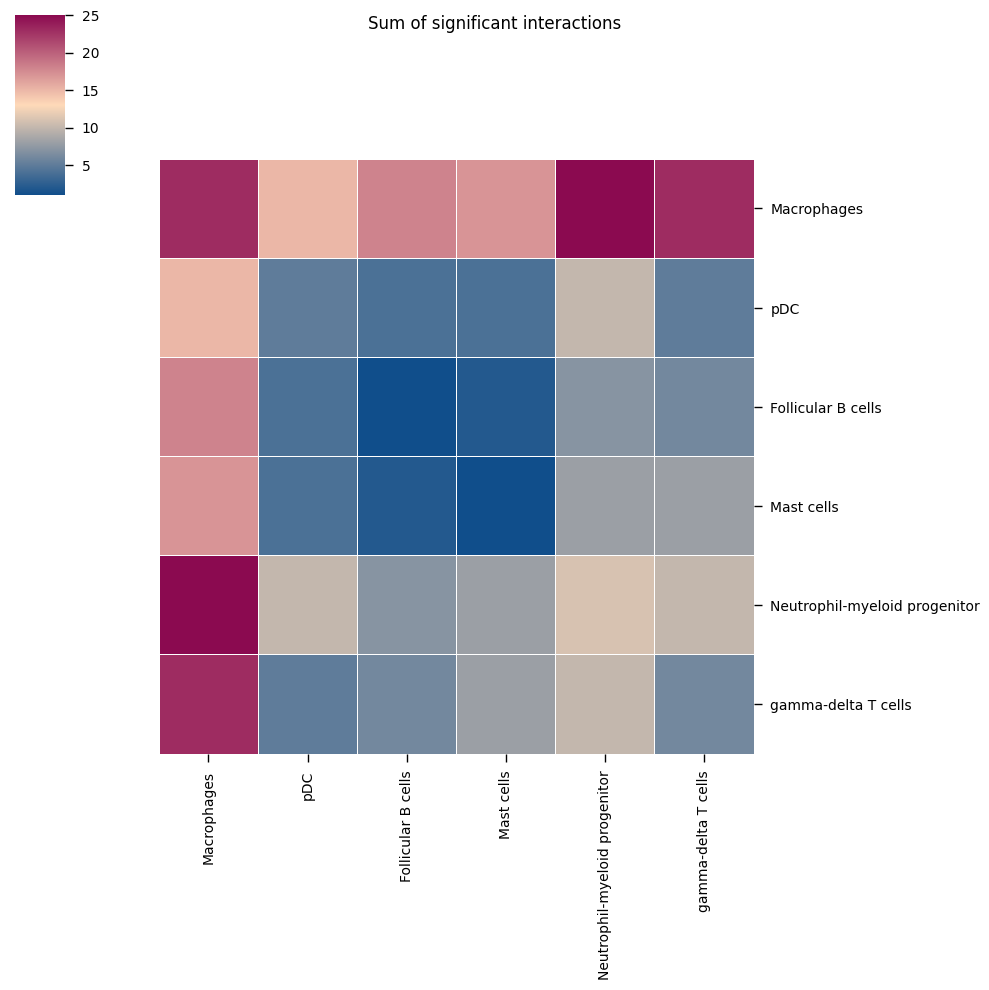

In [9]:
import os
import anndata as ad
import pandas as pd
import ktplotspy as kpy
import matplotlib.pyplot as plt
%matplotlib inline

kpy.plot_cpdb_heatmap(pvals = cpdb_results['pvalues'],
                      degs_analysis = False,
                      figsize = (10, 10),
                      title = "Sum of significant interactions")